## GRID CLUSTERING

12 cellules denses trouvées
3 clusters détectés.


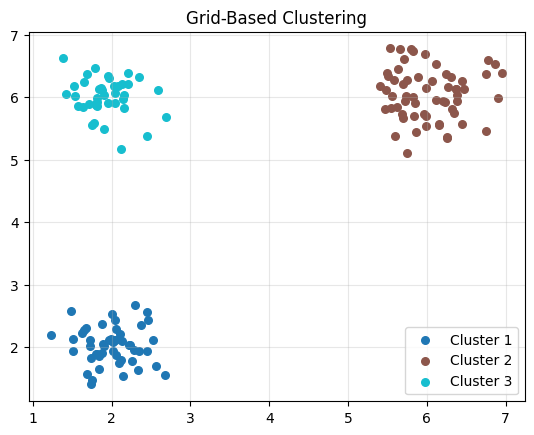

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from itertools import product

# =============================
# 1. Génération de données
# =============================
np.random.seed(0)
X1 = np.random.normal([2, 2], 0.3, size=(50, 2))
X2 = np.random.normal([6, 6], 0.4, size=(60, 2))
X3 = np.random.normal([2, 6], 0.3, size=(40, 2))
data = np.vstack([X1, X2, X3])

# =============================
# 2. Paramètres de la grille
# =============================
grid_size = 1.0   # Taille des cellules
tau = 5           # Seuil de densité minimale

# =============================
# 3. Assignation aux cellules
# =============================
# On arrondit les coordonnées selon la taille de grille
grid_coords = np.floor(data / grid_size)

# Dictionnaire: clé = cellule, valeur = liste d’indices
cells = {}
for i, coord in enumerate(map(tuple, grid_coords)):
    cells.setdefault(coord, []).append(i)

# =============================
# 4. Calcul de densité
# =============================
dense_cells = {cell: idxs for cell, idxs in cells.items() if len(idxs) >= tau}

print(f"{len(dense_cells)} cellules denses trouvées")

# =============================
# 5. Construction des clusters
# =============================
visited = set()
clusters = []

def get_neighbors(cell):
    """Renvoie les cellules voisines (8 connexions en 2D)."""
    offsets = list(product([-1, 0, 1], repeat=2))
    return [(cell[0]+dx, cell[1]+dy) for dx, dy in offsets if not (dx == dy == 0)]

for cell in dense_cells:
    if cell in visited:
        continue
    cluster = set()
    stack = [cell]
    while stack:
        c = stack.pop()
        if c in visited or c not in dense_cells:
            continue
        visited.add(c)
        cluster.add(c)
        stack.extend(get_neighbors(c))
    clusters.append(cluster)

print(f"{len(clusters)} clusters détectés.")

# =============================
# 6. Visualisation
# =============================
colors = plt.cm.tab10(np.linspace(0, 1, len(clusters)))

for i, cluster in enumerate(clusters):
    points = [idx for cell in cluster for idx in dense_cells[cell]]
    plt.scatter(data[points, 0], data[points, 1], s=30, color=colors[i], label=f"Cluster {i+1}")

plt.title("Grid-Based Clustering")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


## SUBSPACE CLUSTERING

Nombre de clusters trouvés : 4
Indices des points du 1er cluster : [2, 4, 5, 7]


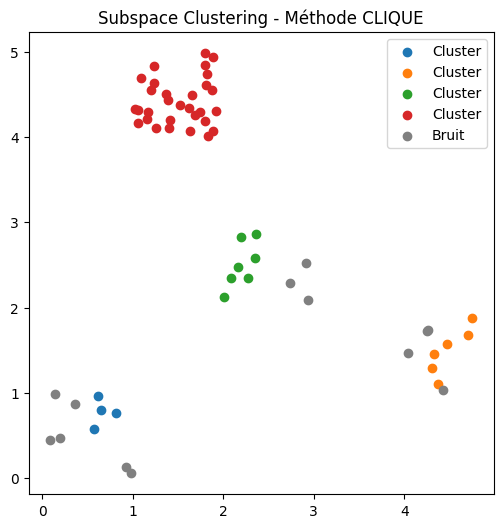

In [5]:
from pyclustering.cluster.clique import clique
from pyclustering.utils import read_sample
from pyclustering.samples.definitions import SIMPLE_SAMPLES
import matplotlib.pyplot as plt

# 1️⃣ Charger un jeu de données simple
sample = read_sample(SIMPLE_SAMPLES.SAMPLE_SIMPLE3)

# 2️⃣ Définir les paramètres
intervals = 10      # nombre de divisions de la grille
threshold = 2       # densité minimale d’un cluster

# 3️⃣ Créer et entraîner l’algorithme CLIQUE
clique_instance = clique(sample, intervals, threshold)
clique_instance.process()

# 4️⃣ Récupérer les clusters
clusters = clique_instance.get_clusters()
noise = clique_instance.get_noise()

print("Nombre de clusters trouvés :", len(clusters))
print("Indices des points du 1er cluster :", clusters[0])

# 5️⃣ Visualisation
plt.figure(figsize=(6,6))
for cluster in clusters:
    points = [sample[i] for i in cluster]
    x, y = zip(*points)
    plt.scatter(x, y, label='Cluster')
    
if noise:
    noise_points = [sample[i] for i in noise]
    x, y = zip(*noise_points)
    plt.scatter(x, y, color='grey', label='Bruit')

plt.title("Subspace Clustering - Méthode CLIQUE")
plt.legend()
plt.show()
